In [ ]:
import pandas as pd
import numpy as np
import librosa
from collections import defaultdict
import soundfile as sf
import wfdb
import os
import re
import cv2
from tqdm import tqdm
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
import pywt

from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import load_model


from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

2026-03-23 00:53:55.896554: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 00:53:55.905458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 00:53:55.916061: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 00:53:55.919378: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-23 00:53:55.927324: I tensorflow/core/platform/cpu_feature_guar

In [2]:
print('Num GPUs Available: ', len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


I0000 00:00:1774227237.440626  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774227237.475442  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774227237.476463  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory Growth Enabled")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

✅ Memory Growth Enabled


Dataset: https://physionet.org/content/circor-heart-sound/1.0.3/

In [4]:
def top_2_mean(x):
    return x.nlargest(2).mean()

In [5]:
def add_gaussian_noise(spec, noise_factor=0.02):
    noise = np.random.randn(*spec.shape)
    return spec + noise_factor * noise

In [6]:
def random_time_mask(spec, max_mask_size=10):
    spec = spec.copy()
    t = spec.shape[1]

    mask_size = np.random.randint(1, max_mask_size)
    t0 = np.random.randint(0, t - mask_size)

    spec[:, t0:t0 + mask_size] = 0
    return spec

In [7]:
def random_freq_mask(spec, max_mask_size=10):
    spec = spec.copy()
    f = spec.shape[0]
    mask_size = np.random.randint(1, max_mask_size)
    f0 = np.random.randint(0, f - mask_size)
    spec[f0:f0 + mask_size, :] = 0
    return spec

In [8]:
def slice_audio_windows(wav_path, sr=8000, window_sec=3.0, hop_sec=1.5):
    """
    Slices an audio file into fixed-length overlapping windows.
    window_sec: How long each clip should be (e.g., 3 seconds).
    hop_sec: How far to slide the window forward for the next clip. 
             (1.5s means a 50% overlap).
    """
    y, sr = librosa.load(wav_path, sr=sr)
    
    # Convert seconds to sample indices
    window_len = int(window_sec * sr)
    hop_len = int(hop_sec * sr)
    
    clips = []
    
    # Slide the window across the audio array
    for start in range(0, len(y) - window_len + 1, hop_len):
        end = start + window_len
        clip = y[start:end]
        clips.append(clip)
        
    return clips

In [9]:
def extract_clinical_data(record_name):
    record = wfdb.rdheader(record_name)
    metadata = {}
    for comment in record.comments:
        if ':' in comment:
            key, value = comment.split(': ')
            metadata[key] = value
    return metadata

In [10]:
def parse_patient_data(data_dir):
    patient_records = []
    # Find all the text files that start with a number
    txt_files = [f for f in os.listdir(data_dir) if f.endswith('.txt') and f[0].isdigit()]

    for txt_file in txt_files:
        path = os.path.join(data_dir, txt_file)
        with open(path, 'r') as f:
            content = f.read()
            
        # Extract basic clinical metadata
        age = re.search(r'#Age: (.*)', content).group(1)
        sex = re.search(r'#Sex: (.*)', content).group(1)
        outcome = re.search(r'#Outcome: (.*)', content).group(1)
        
        wav_names = re.findall(r'[a-zA-Z0-9_]+\.wav', content)
        
        for wav_name in wav_names:
            # Extract the valve directly from the filename!
            # Example: "50122_PV.wav" -> split by '_' -> ["50122", "PV.wav"] 
            # -> split by '.' -> ["PV", "wav"] -> "PV"
            try:
                valve_type = wav_name.split('_')[1].split('.')[0]
            except IndexError:
                # Fallback just in case a weird filename exists
                valve_type = "Unknown" 
                
            patient_records.append({
                'patient_id': txt_file.replace('.txt', ''),
                'valve': valve_type,
                'wav_path': os.path.join(data_dir, wav_name),
                'age': age,
                'sex': sex,
                'label': 1 if outcome == 'Abnormal' else 0
            })
            
    return pd.DataFrame(patient_records)

In [11]:
def create_cwt_image(clip, wavelet='morl', target_shape=(256, 100)):
    scales = np.geomspace(5, 150, num=128)
    coef, _ = pywt.cwt(clip, scales, wavelet)
    coef = np.abs(coef)
    c_min, c_max = np.min(coef), np.max(coef)
    coef = (coef - c_min) / (c_max - c_min + 1e-8)
    coef = cv2.resize(coef, (target_shape[1], target_shape[0]))
    return coef

In [ ]:
def build_manifest(df, output_dir='processed_cwt_windows'):
    os.makedirs(output_dir, exist_ok=True)
    manifest_rows = []
    
    # Check if the CSV exists
    if not os.path.exists('manifest_cwt_windows.csv'):
        print("Starting CWT precomputation using Fixed Windows...")
        for row in tqdm(df.itertuples(), total=len(df)):

            try:
                # NEW: Use the fixed-window slicer instead of slice_heartbeats
                clips = slice_audio_windows(row.wav_path, window_sec=3.0, hop_sec=1.5)
            except Exception as e:
                print(f"Error processing {row.wav_path}: {e}")
                continue

            for i, clip in enumerate(clips):
                # Ensure the clip isn't completely silent or somehow tiny
                if clip is None or len(clip) < 50:
                    continue
                    
                spec = create_cwt_image(clip)
                spec = np.log1p(np.abs(spec))
                spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)
                
                # Tagging the file with 'win' so you know it's a window, not a single beat
                filename = f"{row.patient_id}_{row.valve}_win_{i}.npy"
                file_save_path = os.path.join(output_dir, filename)
                np.save(file_save_path, spec)
                
                manifest_rows.append({
                    'file_path': file_save_path,
                    'Patient ID': row.patient_id, # Make sure 'Patient ID' matches your training code exactly
                    'valve': row.valve
                })
                
        manifest_df = pd.DataFrame(manifest_rows)
        manifest_df.to_csv('manifest_cwt_windows.csv', index=False)
    else:
        print("Data already generated, copying from csv...")
        manifest_df = pd.read_csv('manifest_cwt_windows.csv')
        
    return manifest_df

In [13]:
class HeartDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, shuffle=True, augment=False):
        self.df = df
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()
    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))
    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)
    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size]
        X_audio, X_clinical, y = [], [], []
        for row in batch.itertuples():
            spec = np.load(row.file_path)
            if self.augment:
                if np.random.rand() < 0.5:
                    spec = add_gaussian_noise(spec)
                if np.random.rand() < 0.5:
                    spec = random_time_mask(spec)
                if np.random.rand() < 0.5:
                    spec = random_freq_mask(spec)
                spec = np.clip(spec, 0, 1)
                spec = np.roll(spec, shift=np.random.randint(-20, 20), axis=1)
            X_audio.append(spec[..., np.newaxis])
            X_clinical.append([
                row.age, row.sex, row.Height, row.Weight,
                row.pregnant, row.valve_AV, row.valve_MV,
                row.valve_PV, row.valve_TV
            ])
            y.append(row.y)
        return {
            "audio_input": np.array(X_audio, dtype=np.float32),
            "clinical_input": np.array(X_clinical, dtype=np.float32)
        }, np.array(y, dtype=np.int32)

In [ ]:
def build_fusion_model(input_shape=(256, 100, 1), clinical_shape=(9,)):
    # Audio
    audio_in = layers.Input(shape=input_shape, name="audio_input")
    # 1 canal a 3 canales
    x = layers.Conv2D(3, (1, 1), padding='same', name="channel_expander")(audio_in)
    # EfficientNetB0
    base_model = EfficientNetB0(
        include_top=False, 
        weights='imagenet', 
        input_shape=(input_shape[0], input_shape[1], 3)
    )
    # will be kept as untrainable to warm it up
    base_model.trainable = False
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)

    # Clinical metadata
    clinical_in = layers.Input(shape=clinical_shape, name="clinical_input")
    y = layers.Dense(64, activation='relu')(clinical_in)
    y = layers.BatchNormalization()(y)
    y = layers.Dense(32, activation='relu')(y)
    y = layers.Dropout(0.4)(y)

    # Fusion
    combined = layers.concatenate([x, y])
    z = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(combined)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(z)

    output = layers.Dense(1, activation='sigmoid', name="output")(z)
    model = models.Model(inputs=[audio_in, clinical_in], outputs=output)

    return model

In [15]:
df = parse_patient_data('./data/physionet.org/files/circor-heart-sound/1.0.3/training_data/')

In [16]:
df.head()

,patient_id,valve,wav_path,age,sex,label
0,50122,PV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
1,50122,TV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
2,50122,MV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
3,50079,AV,./data/physionet.org/files/circor-heart-sound/...,Child,Female,0
4,50079,PV,./data/physionet.org/files/circor-heart-sound/...,Child,Female,0


In [17]:
final_manifest = build_manifest(df)

Data already generated, copying from csv...


In [18]:
df.head()

,patient_id,valve,wav_path,age,sex,label
0,50122,PV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
1,50122,TV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
2,50122,MV,./data/physionet.org/files/circor-heart-sound/...,Child,Male,0
3,50079,AV,./data/physionet.org/files/circor-heart-sound/...,Child,Female,0
4,50079,PV,./data/physionet.org/files/circor-heart-sound/...,Child,Female,0


In [19]:
df['patient_id'] = df['patient_id'].astype(int)
df.rename(columns={'patient_id': 'Patient ID'}, inplace=True)
final_manifest['Patient ID'] = final_manifest['Patient ID'].astype(int)

In [20]:
final_manifest.head()

,file_path,Patient ID,valve
0,processed_cwt_windows/50122_PV_win_0.npy,50122,PV
1,processed_cwt_windows/50122_PV_win_1.npy,50122,PV
2,processed_cwt_windows/50122_PV_win_2.npy,50122,PV
3,processed_cwt_windows/50122_PV_win_3.npy,50122,PV
4,processed_cwt_windows/50122_PV_win_4.npy,50122,PV


In [21]:
clinical_data = pd.read_csv('./data/physionet.org/files/circor-heart-sound/1.0.3/training_data.csv')

In [22]:
clinical_data.head()

,Patient ID,Recording locations:,Age,Sex,Height,Weight,Pregnancy status,Murmur,Murmur locations,Most audible location,Systolic murmur timing,Systolic murmur shape,Systolic murmur grading,Systolic murmur pitch,Systolic murmur quality,Diastolic murmur timing,Diastolic murmur shape,Diastolic murmur grading,Diastolic murmur pitch,Diastolic murmur quality,Outcome,Campaign,Additional ID
0,2530,AV+PV+TV+MV,Child,Female,98.0,15.9,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
1,9979,AV+PV+TV+MV,Child,Female,103.0,13.1,False,Present,AV+MV+PV+TV,TV,Holosystolic,Diamond,III/VI,High,Harsh,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
2,9983,AV+PV+TV+MV,Child,Male,115.0,19.1,False,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
3,13918,AV+PV+TV+MV,Child,Male,98.0,15.9,False,Present,TV,TV,Holosystolic,Plateau,I/VI,Low,Blowing,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN
4,14241,AV+PV+TV+MV,Child,Male,87.0,11.2,False,Present,AV+MV+PV+TV,PV,Early-systolic,Plateau,II/VI,Low,Harsh,NaN,NaN,NaN,NaN,NaN,Abnormal,CC2015,NaN


In [23]:
comb_df = final_manifest.merge(clinical_data, on=['Patient ID'])

In [24]:
comb_df.head()

,file_path,Patient ID,valve,Recording locations:,Age,Sex,Height,Weight,Pregnancy status,Murmur,Murmur locations,Most audible location,Systolic murmur timing,Systolic murmur shape,Systolic murmur grading,Systolic murmur pitch,Systolic murmur quality,Diastolic murmur timing,Diastolic murmur shape,Diastolic murmur grading,Diastolic murmur pitch,Diastolic murmur quality,Outcome,Campaign,Additional ID
0,processed_cwt_windows/50122_PV_win_0.npy,50122,PV,PV+TV+MV,Child,Male,123.0,22.7,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN
1,processed_cwt_windows/50122_PV_win_1.npy,50122,PV,PV+TV+MV,Child,Male,123.0,22.7,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN
2,processed_cwt_windows/50122_PV_win_2.npy,50122,PV,PV+TV+MV,Child,Male,123.0,22.7,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN
3,processed_cwt_windows/50122_PV_win_3.npy,50122,PV,PV+TV+MV,Child,Male,123.0,22.7,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN
4,processed_cwt_windows/50122_PV_win_4.npy,50122,PV,PV+TV+MV,Child,Male,123.0,22.7,False,Absent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,CC2014,NaN


In [25]:
comb_df = comb_df.drop(columns=['Recording locations:', 'Campaign', 'Murmur locations','Most audible location','Systolic murmur timing','Systolic murmur shape','Systolic murmur grading','Systolic murmur pitch','Systolic murmur quality',
                      'Diastolic murmur timing','Diastolic murmur shape','Diastolic murmur grading','Diastolic murmur pitch','Diastolic murmur quality', 'Murmur'])

In [26]:
comb_df.head()

,file_path,Patient ID,valve,Age,Sex,Height,Weight,Pregnancy status,Outcome,Additional ID
0,processed_cwt_windows/50122_PV_win_0.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN
1,processed_cwt_windows/50122_PV_win_1.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN
2,processed_cwt_windows/50122_PV_win_2.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN
3,processed_cwt_windows/50122_PV_win_3.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN
4,processed_cwt_windows/50122_PV_win_4.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN


In [27]:
comb_df['Master_ID'] = comb_df['Additional ID'].fillna(comb_df['Patient ID'])

In [28]:
comb_df['Age'].value_counts()

Age
Child         32040
Infant         3786
Adolescent     3639
Neonate         139
Name: count, dtype: int64

In [29]:
comb_df['Sex'].value_counts()

Sex
Female    22440
Male      21051
Name: count, dtype: int64

In [30]:
comb_df['Pregnancy status'].value_counts()

Pregnancy status
False    39948
True      3543
Name: count, dtype: int64

In [31]:
comb_df['Outcome'].value_counts()

Outcome
Normal      22418
Abnormal    21073
Name: count, dtype: int64

In [32]:
age_map = {'Neonate': 0, 'Infant': 1, 'Child': 2, 'Adolescent': 3, 'Adult': 4}
sex_map = {'Male': 0, 'Female': 1}
pregnancy_map = {True: 1, False:0}
outcome_map = {'Normal': 0, 'Abnormal':1}

comb_df['age'] = comb_df['Age'].map(age_map).fillna(2)
comb_df['sex'] = comb_df['Sex'].map(sex_map)
comb_df['pregnant'] = comb_df['Pregnancy status'].map(pregnancy_map)
comb_df['y'] = comb_df['Outcome'].map(outcome_map)

In [33]:
comb_df.head()

,file_path,Patient ID,valve,Age,Sex,Height,Weight,Pregnancy status,Outcome,Additional ID,Master_ID,age,sex,pregnant,y
0,processed_cwt_windows/50122_PV_win_0.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN,50122.0,2.0,0,0,0
1,processed_cwt_windows/50122_PV_win_1.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN,50122.0,2.0,0,0,0
2,processed_cwt_windows/50122_PV_win_2.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN,50122.0,2.0,0,0,0
3,processed_cwt_windows/50122_PV_win_3.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN,50122.0,2.0,0,0,0
4,processed_cwt_windows/50122_PV_win_4.npy,50122,PV,Child,Male,123.0,22.7,False,Normal,NaN,50122.0,2.0,0,0,0


In [34]:
comb_df.isna().cumsum().tail(1)

,file_path,Patient ID,valve,Age,Sex,Height,Weight,Pregnancy status,Outcome,Additional ID,Master_ID,age,sex,pregnant,y
43490,0,0,0,3887,0,5392,4969,0,0,36973,0,0,0,0,0


In [35]:
comb_df['Height'] = comb_df['Height'].fillna(comb_df['Height'].median())
comb_df['Weight'] = comb_df['Weight'].fillna(comb_df['Weight'].median())

In [36]:
df = comb_df[['Master_ID', 'age','sex','Height','Weight','pregnant','valve','file_path','y']].copy()

In [37]:
df.isna().cumsum().tail(1)

,Master_ID,age,sex,Height,Weight,pregnant,valve,file_path,y
43490,0,0,0,0,0,0,0,0,0


In [38]:
valve_dummies = pd.get_dummies(df['valve'], prefix='valve')
df = pd.concat([df, valve_dummies], axis=1)
df = df.drop(columns=['valve'])
bool_cols = ['valve_AV', 'valve_MV', 'valve_PV', 'valve_TV']
df[bool_cols] = df[bool_cols].astype(int)
df.drop(columns=['valve_Phc'], inplace=True)

In [39]:
df.head()

,Master_ID,age,sex,Height,Weight,pregnant,file_path,y,valve_AV,valve_MV,valve_PV,valve_TV
0,50122.0,2.0,0,123.0,22.7,0,processed_cwt_windows/50122_PV_win_0.npy,0,0,0,1,0
1,50122.0,2.0,0,123.0,22.7,0,processed_cwt_windows/50122_PV_win_1.npy,0,0,0,1,0
2,50122.0,2.0,0,123.0,22.7,0,processed_cwt_windows/50122_PV_win_2.npy,0,0,0,1,0
3,50122.0,2.0,0,123.0,22.7,0,processed_cwt_windows/50122_PV_win_3.npy,0,0,0,1,0
4,50122.0,2.0,0,123.0,22.7,0,processed_cwt_windows/50122_PV_win_4.npy,0,0,0,1,0


In [40]:
df.isna().cumsum().tail(1)

,Master_ID,age,sex,Height,Weight,pregnant,file_path,y,valve_AV,valve_MV,valve_PV,valve_TV
43490,0,0,0,0,0,0,0,0,0,0,0,0


In [41]:
df.dtypes

Master_ID    float64
age          float64
sex            int64
Height       float64
Weight       float64
pregnant       int64
file_path     object
y              int64
valve_AV       int64
valve_MV       int64
valve_PV       int64
valve_TV       int64
dtype: object

In [42]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=777)
train_idx, val_idx = next(gss.split(df, groups=df['Master_ID']))

In [43]:
train_data = df.iloc[train_idx].copy()
val_data = df.iloc[val_idx].copy()

scaler = MinMaxScaler()
num_cols = ['Height', 'Weight']
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
val_data[num_cols] = scaler.transform(val_data[num_cols])

joblib.dump(scaler, 'hw_scaler.pkl')

['hw_scaler.pkl']

In [44]:
train_data['file_path'] = train_data['file_path'].astype(str)
val_data['file_path'] = val_data['file_path'].astype(str)

In [45]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data['y']),
    y=train_data['y']
)
class_weights = dict(enumerate(weights))

In [46]:
train_gen = HeartDataGenerator(train_data, batch_size=32, shuffle=True, augment=True)
val_gen = HeartDataGenerator(val_data, batch_size=32, shuffle=False, augment=False)

## Model training

In [47]:
model = build_fusion_model(input_shape=(256, 100, 1), clinical_shape=(9,))

I0000 00:00:1774107934.430769    6215 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774107934.432016    6215 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774107934.432594    6215 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774107934.526880    6215 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [48]:
model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.5),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

In [49]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 audio_input (InputLayer)    [(None, 256, 100, 1)]        0         []                            
                                                                                                  
 clinical_input (InputLayer  [(None, 9)]                  0         []                            
 )                                                                                                
                                                                                                  
 channel_expander (Conv2D)   (None, 256, 100, 3)          6         ['audio_input[0][0]']         
                                                                                                  
 dense (Dense)               (None, 64)                   640       ['clinical_input[0][0]']  

In [50]:
model.fit(train_gen, validation_data=val_gen, epochs=5, class_weight=class_weights)

Epoch 1/5


2026-03-21 15:45:43.280433: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature

   1/1092 [..............................] - ETA: 2:21:00 - loss: 0.7774 - accuracy: 0.5000 - auc: 0.4838

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1774107945.800887    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.802651    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.802998    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.803559    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.804106    6769 gpu_timer.cc:114] Skipping the delay kernel, measu

   7/1092 [..............................] - ETA: 33s - loss: 0.7956 - accuracy: 0.4777 - auc: 0.4688  

W0000 00:00:1774107945.934409    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.934941    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.935456    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.935998    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.936712    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.938910    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.939831    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.940817    6769 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774107945.942313    6769 gp

1092/1092 [==============================] - 40s 29ms/step - loss: 0.5728 - accuracy: 0.5055 - auc: 0.5071 - val_loss: 0.4593 - val_accuracy: 0.5325 - val_auc: 0.5517
Epoch 2/5
1092/1092 [==============================] - 31s 28ms/step - loss: 0.4729 - accuracy: 0.5076 - auc: 0.5110 - val_loss: 0.4212 - val_accuracy: 0.5704 - val_auc: 0.5700
Epoch 3/5
1092/1092 [==============================] - 31s 28ms/step - loss: 0.4246 - accuracy: 0.5087 - auc: 0.5122 - val_loss: 0.3806 - val_accuracy: 0.5812 - val_auc: 0.5624
Epoch 4/5
1092/1092 [==============================] - 31s 28ms/step - loss: 0.3787 - accuracy: 0.5138 - auc: 0.5210 - val_loss: 0.3409 - val_accuracy: 0.5627 - val_auc: 0.5850
Epoch 5/5
1092/1092 [==============================] - 31s 28ms/step - loss: 0.3356 - accuracy: 0.5175 - auc: 0.5307 - val_loss: 0.3050 - val_accuracy: 0.5309 - val_auc: 0.5963


In [51]:
model.trainable = True

In [52]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.5), metrics=['accuracy', 'AUC'])

In [53]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max')

checkpoint = tf.keras.callbacks.ModelCheckpoint('models/production/model_EffNet_val_auc_{val_auc:.4f}.keras',
                             save_best_only=True,
                             save_weights_only=False,
                             monitor='val_auc',
                             mode='max')
reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6)

In [54]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint, reduce]
)

Epoch 1/50


2026-03-21 15:48:32.443659: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1026] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature

   4/1092 [..............................] - ETA: 46s - loss: 0.3323 - accuracy: 0.5703 - auc: 0.5740   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1774108119.841642    6770 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774108119.844130    6770 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774108119.844465    6770 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be 

1092/1092 [==============================] - 65s 42ms/step - loss: 0.3274 - accuracy: 0.5151 - auc: 0.5259 - val_loss: 0.3123 - val_accuracy: 0.5032 - val_auc: 0.5586 - lr: 1.0000e-05
Epoch 2/50
1092/1092 [==============================] - 45s 41ms/step - loss: 0.3235 - accuracy: 0.5189 - auc: 0.5279 - val_loss: 0.3077 - val_accuracy: 0.5256 - val_auc: 0.5692 - lr: 1.0000e-05
Epoch 3/50
1092/1092 [==============================] - 45s 41ms/step - loss: 0.3195 - accuracy: 0.5224 - auc: 0.5339 - val_loss: 0.3029 - val_accuracy: 0.5566 - val_auc: 0.5929 - lr: 1.0000e-05
Epoch 4/50
1092/1092 [==============================] - 44s 40ms/step - loss: 0.3160 - accuracy: 0.5247 - auc: 0.5374 - val_loss: 0.3030 - val_accuracy: 0.5164 - val_auc: 0.5722 - lr: 1.0000e-05
Epoch 5/50
1092/1092 [==============================] - 44s 41ms/step - loss: 0.3134 - accuracy: 0.5265 - auc: 0.5396 - val_loss: 0.3005 - val_accuracy: 0.5430 - val_auc: 0.6037 - lr: 5.0000e-06
Epoch 6/50
1092/1092 [==============

## Predictions

In [47]:
all_audio = []
all_clinical = []
all_labels = []

for i in range(len(val_gen)):
    inputs, labels = val_gen[i]
    all_audio.append(inputs['audio_input'])
    all_clinical.append(inputs['clinical_input'])
    all_labels.append(labels)
X_audio_test = np.vstack(all_audio)
X_clinical_test = np.vstack(all_clinical)
y_true = np.concatenate(all_labels)
print(f"Total test samples collected: {len(y_true)}")

Total test samples collected: 8512


In [ ]:
# the kernel should be reset as it takes a lot of VRAM
model = tf.keras.models.load_model('models/production/model_EffNet_val_auc_0.6708.keras') 
print("Model loaded successfully!")

I0000 00:00:1774227252.271738  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774227252.272787  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774227252.273588  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1774227252.355741  187003 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model loaded successfully!


In [49]:
test_ds = tf.data.Dataset.from_tensor_slices(({
    "audio_input": X_audio_test,
    "clinical_input": X_clinical_test
},)).batch(32).prefetch(tf.data.AUTOTUNE)
y_probs = model.predict(test_ds)
y_val_true = val_data['y'].values[:len(val_gen)*32]

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 14/266 [>.............................] - ETA: 2s

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1774227267.280254  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.280390  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.280498  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.280604  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.280706  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.280918  187308 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1774227267.281068  187308 gpu_timer.cc:114] Skipping

266/266 [==============================] - 4s 8ms/step


In [ ]:
fpr, tpr, thresholds = roc_curve(y_val_true, y_probs)

# Youden J statistic
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]
print("Best threshold:", best_threshold)

Best threshold: 0.5020466


In [51]:
y_pred = (y_probs > best_threshold).astype(int)

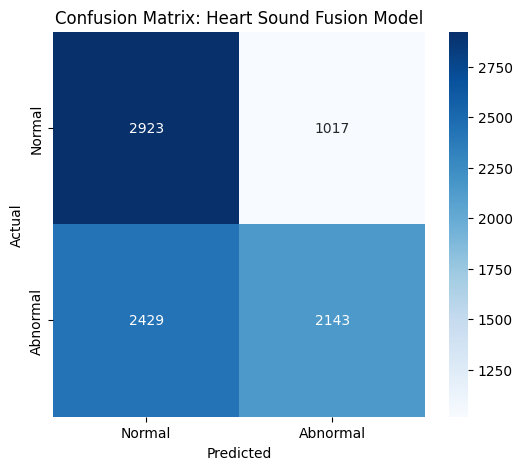

              precision    recall  f1-score   support

           0       0.55      0.74      0.63      3940
           1       0.68      0.47      0.55      4572

    accuracy                           0.60      8512
   macro avg       0.61      0.61      0.59      8512
weighted avg       0.62      0.60      0.59      8512



In [52]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Abnormal'], 
            yticklabels=['Normal', 'Abnormal'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Heart Sound Fusion Model')
plt.show()

print(classification_report(y_true, y_pred))

In [53]:
window_predictions =model.predict(val_gen)
y_probs = window_predictions.flatten()
val_data = val_data.iloc[:len(window_predictions)]
val_data['window_prob'] = window_predictions
y_true = val_data['y'].values[:len(val_gen)*32]
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
optimal_idx = np.argmax(tpr - fpr)
best_t = thresholds[optimal_idx]
print(f"The 'Magic' Threshold for this model is: {best_t:.4f}")
y_pred_tuned = (y_probs > best_t).astype(int)
print("\n--- TUNED SEGMENT-LEVEL REPORT ---")
print(classification_report(y_true, y_pred_tuned))

266/266 [==============================] - 3s 8ms/step
The 'Magic' Threshold for this model is: 0.5020

--- TUNED SEGMENT-LEVEL REPORT ---
              precision    recall  f1-score   support

           0       0.55      0.75      0.63      3940
           1       0.68      0.47      0.56      4572

    accuracy                           0.60      8512
   macro avg       0.61      0.61      0.59      8512
weighted avg       0.62      0.60      0.59      8512



In [ ]:
# Group the windows back into patients
patient_results = val_data.groupby('Master_ID').agg(
    true_label=('y', 'first'),
    patient_prob=('window_prob', top_2_mean)
).reset_index()

# Convert probabilities to a hard class (0 or 1) using a 0.5 threshold
patient_results['patient_pred_class'] = (patient_results['patient_prob'] > 0.5).astype(int)

In [55]:
patient_accuracy = accuracy_score(patient_results['true_label'], patient_results['patient_pred_class'])
patient_auc = roc_auc_score(patient_results['true_label'], patient_results['patient_prob'])

print(f"Patient-Level Accuracy: {patient_accuracy:.4f}")
print(f"Patient-Level AUC: {patient_auc:.4f}")

# See exactly how it did on normal vs abnormal
print("\nClassification Report:")
print(classification_report(patient_results['true_label'], patient_results['patient_pred_class']))

Patient-Level Accuracy: 0.5926
Patient-Level AUC: 0.7595

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.15      0.27        91
           1       0.56      1.00      0.72        98

    accuracy                           0.59       189
   macro avg       0.78      0.58      0.49       189
weighted avg       0.77      0.59      0.50       189



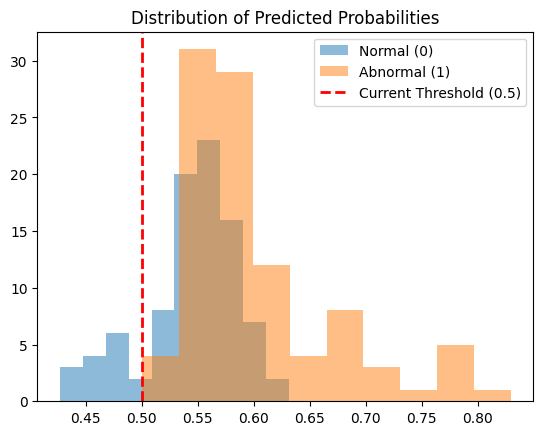

In [ ]:
plt.hist(patient_results[patient_results['true_label'] == 0]['patient_prob'], alpha=0.5, label='Normal (0)')
plt.hist(patient_results[patient_results['true_label'] == 1]['patient_prob'], alpha=0.5, label='Abnormal (1)')
plt.axvline(0.5, color='red', linestyle='dashed', linewidth=2, label='Current Threshold (0.5)')
plt.legend()
plt.title("Distribution of Predicted Probabilities")
plt.show()

In [ ]:
fpr, tpr, thresholds = roc_curve(patient_results['true_label'], patient_results['patient_prob'])
optimal_threshold = thresholds[np.argmax(tpr - fpr)]

Do not use 0.5! The optimal Focal Loss threshold is: 0.5623


In [ ]:
patient_results['optimized_pred_class'] = (patient_results['patient_prob'] > optimal_threshold).astype(int)

# Recalculate metrics
optimized_accuracy = accuracy_score(patient_results['true_label'], patient_results['optimized_pred_class'])

print(f"Optimized Patient-Level Accuracy: {optimized_accuracy:.4f}")
print("\nOptimized Classification Report:")
print(classification_report(patient_results['true_label'], patient_results['optimized_pred_class']))

Optimized Patient-Level Accuracy: 0.6878

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.68        91
           1       0.71      0.67      0.69        98

    accuracy                           0.69       189
   macro avg       0.69      0.69      0.69       189
weighted avg       0.69      0.69      0.69       189



In [59]:
patient_results

,Master_ID,true_label,patient_prob,patient_pred_class,optimized_pred_class
0,9979.0,1,0.734224,1,1
1,14998.0,1,0.593212,1,1
2,29045.0,1,0.556586,1,0
3,29378.0,1,0.572680,1,1
4,44514.0,1,0.630361,1,1
...,...,...,...,...,...
184,85315.0,1,0.562300,1,0
185,85316.0,0,0.543207,1,0
186,85322.0,0,0.562186,1,0
187,85332.0,0,0.470475,0,0


In [60]:
patient_results[patient_results['true_label']==0]

,Master_ID,true_label,patient_prob,patient_pred_class,optimized_pred_class
11,49653.0,0,0.581804,1,1
20,49969.0,0,0.613911,1,1
22,49987.0,0,0.566588,1,1
23,49990.0,0,0.543218,1,0
24,50004.0,0,0.581638,1,1
...,...,...,...,...,...
181,85264.0,0,0.631446,1,1
185,85316.0,0,0.543207,1,0
186,85322.0,0,0.562186,1,0
187,85332.0,0,0.470475,0,0
